In [97]:
#General Packages
import pandas as pd
import torch
import torch.nn.functional as F
import ast
import scipy.stats as stats
import os

#Statistical tests
import statsmodels.formula.api as smf

#Plot
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

In [98]:
directory = '../results/'

df = pd.concat(
    [pd.read_csv(os.path.join(directory, f)) for f in os.listdir(directory) if f.endswith('.csv')],
    ignore_index=True
).drop_duplicates()

In [99]:
nan_rows = df[df.isna().any(axis=1)]
df.loc[df['first_success_iter'].isna(), 'attack_successful'] = False
df['first_success_iter'] = df['first_success_iter'].fillna(1000000)

In [100]:
model_counts = df['model'].value_counts()
print(model_counts)

model
mobilenet_imagenet20_adv       11808
mobilenet_imagenet20           11808
mobilenet_imagenet20_robust    11808
resnet_imagenet20_adv          11808
resnet_imagenet20              11808
resnet_imagenet20_robust       11808
swin_imagenet20_adv            11808
swin_imagenet20                11808
swin_imagenet20_robust         11808
Name: count, dtype: int64


In [101]:
df_mobilenet = df[df['model'] == 'mobilenet_imagenet20_adv'].copy()
df_resnet    = df[df['model'] == 'resnet_imagenet20_adv'].copy()
df_swin      = df[df['model'] == 'swin_imagenet20_adv'].copy()

df_mobilenet_base = df[df['model'] == 'mobilenet_imagenet20'].copy()
df_resnet_base   = df[df['model'] == 'resnet_imagenet20'].copy()
df_swin_base     = df[df['model'] == 'swin_imagenet20'].copy()

In [102]:
df_models = pd.concat([df_mobilenet, df_resnet, df_swin], ignore_index=True)
df_base = pd.concat([df_mobilenet_base, df_resnet_base, df_swin_base], ignore_index=True)

In [103]:
df_total = pd.concat([df_base,df_models],ignore_index=True)

In [40]:
df_fgsm = df_models[df_models['attack'] == 'fgsm'].copy()
df_cw    = df_models[df_models['attack'] == 'cw'].copy()
df_pgd      = df_models[df_models['attack'] == 'pgd'].copy()

In [41]:
df_attack = pd.concat([df_fgsm, df_cw, df_pgd], ignore_index=True)

### Attacks general statistics

In [42]:
df_fgsm.describe()


,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,1.180800e+04,11808.000000
mean,9.532774,9.480691,9.558181,9.341040,738147.151677,84.937477,0.999993,8.802754e+05,1994.761179
std,5.787412,5.735950,5.819189,5.790326,439657.576068,0.641436,0.000003,6.092396e+05,1151.774203
min,0.000000,0.000000,0.000000,0.000000,0.000000,84.238358,0.999985,5.722418e-01,0.000000
25%,5.000000,5.000000,4.000000,4.000000,56.000000,84.400122,0.999990,1.136486e+01,999.750000
50%,10.000000,9.000000,10.000000,9.000000,1000000.000000,84.568138,0.999993,1.096887e+06,1995.500000
75%,15.000000,14.000000,15.000000,14.000000,1000000.000000,85.662823,0.999996,1.343700e+06,2991.250000
max,19.000000,19.000000,19.000000,19.000000,1000000.000000,88.497604,0.999998,1.565388e+06,3991.000000


In [43]:
df_pgd.describe()


,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,1.180800e+04,11808.000000
mean,9.532774,9.480691,9.558181,9.328675,808868.490091,86.961739,0.999995,7.109783e+05,1994.761179
std,5.787412,5.735950,5.819189,5.765757,393196.211279,1.675140,0.000003,5.087260e+05,1151.774203
min,0.000000,0.000000,0.000000,0.000000,0.000000,85.416412,0.999988,2.839196e-01,0.000000
25%,5.000000,5.000000,4.000000,4.000000,1000000.000000,85.726431,0.999993,9.281417e+00,999.750000
50%,10.000000,9.000000,10.000000,9.000000,1000000.000000,85.907764,0.999994,7.924256e+05,1995.500000
75%,15.000000,14.000000,15.000000,14.000000,1000000.000000,88.571917,0.999998,1.099933e+06,2991.250000
max,19.000000,19.000000,19.000000,19.000000,1000000.000000,93.652077,0.999999,1.364244e+06,3991.000000


In [44]:
df_cw.describe()


,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,1.180800e+04,11808.000000
mean,9.532774,9.486111,9.558181,9.258638,251701.626355,73.448618,0.999861,3.395201e+06,1994.761179
std,5.787412,5.761204,5.819189,5.844576,434000.011526,2.533560,0.000086,2.604893e+06,1151.774203
min,0.000000,0.000000,0.000000,0.000000,1.000000,67.672241,0.999485,9.793813e-01,0.000000
25%,5.000000,5.000000,4.000000,4.000000,4.000000,71.500744,0.999800,4.607121e+01,999.750000
50%,10.000000,9.000000,10.000000,9.000000,9.000000,73.328667,0.999876,3.777446e+06,1995.500000
75%,15.000000,14.000000,15.000000,14.000000,1000000.000000,75.003939,0.999937,5.343365e+06,2991.250000
max,19.000000,19.000000,19.000000,19.000000,1000000.000000,92.812775,0.999999,1.040740e+07,3991.000000


In [45]:
df_attack = df_attack[df_attack["first_success_iter"] != 1000000]
df_attack.groupby('attack')['first_success_iter'].mean()

attack
cw      10.502943
fgsm    13.443402
pgd     52.782898
Name: first_success_iter, dtype: float64

# Successrate

In [ ]:
# Calculate success rates
success_rates = df_mobilenet.groupby('attack')['attack_successful'].mean()
counts = df_mobilenet.groupby('attack')['attack_successful'].sum()
totals = df_mobilenet.groupby('attack')['attack_successful'].count()

# Compute confidence intervals
ci_df_mobilenet = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal') 
    ci_df_mobilenet.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
print(ci_df_mobilenet)

      success_rate       n    ci_low   ci_high
cw        0.023120  3936.0  0.018425  0.027815
fgsm      0.023882  3936.0  0.019112  0.028652
pgd       0.021341  3936.0  0.016827  0.025856


In [ ]:
# Calculate success rates
success_rates = df_resnet.groupby('attack')['attack_successful'].mean()
counts = df_resnet.groupby('attack')['attack_successful'].sum()
totals = df_resnet.groupby('attack')['attack_successful'].count()

# Compute confidence intervals
ci_df_resnet = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal')  
    ci_df_resnet.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
print(ci_df_resnet)

      success_rate       n    ci_low   ci_high
cw        0.265244  3936.0  0.251452  0.279036
fgsm      0.540904  3936.0  0.525336  0.556472
pgd       0.529726  3936.0  0.514133  0.545318


In [ ]:
# Calculate success rates
success_rates = df_swin.groupby('attack')['attack_successful'].mean()
counts = df_swin.groupby('attack')['attack_successful'].sum()
totals = df_swin.groupby('attack')['attack_successful'].count()

# Compute confidence intervals 
ci_df_swin = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal') 
    ci_df_swin.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
print(ci_df_swin)

      success_rate       n    ci_low   ci_high
cw        0.291667  3936.0  0.277467  0.305866
fgsm      0.034045  3936.0  0.028379  0.039710
pgd       0.022104  3936.0  0.017511  0.026697


In [ ]:
# Calculate success rates
success_rates = df_models.groupby('attack')['attack_successful'].mean()
counts = df_models.groupby('attack')['attack_successful'].sum()
totals = df_models.groupby('attack')['attack_successful'].count()

# Compute confidence intervals
ci_df_swin = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal') 
    ci_df_swin.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
print(ci_df_swin)

      success_rate        n    ci_low   ci_high
cw        0.193343  11808.0  0.186220  0.200467
fgsm      0.199610  11808.0  0.192401  0.206820
pgd       0.191057  11808.0  0.183966  0.198148


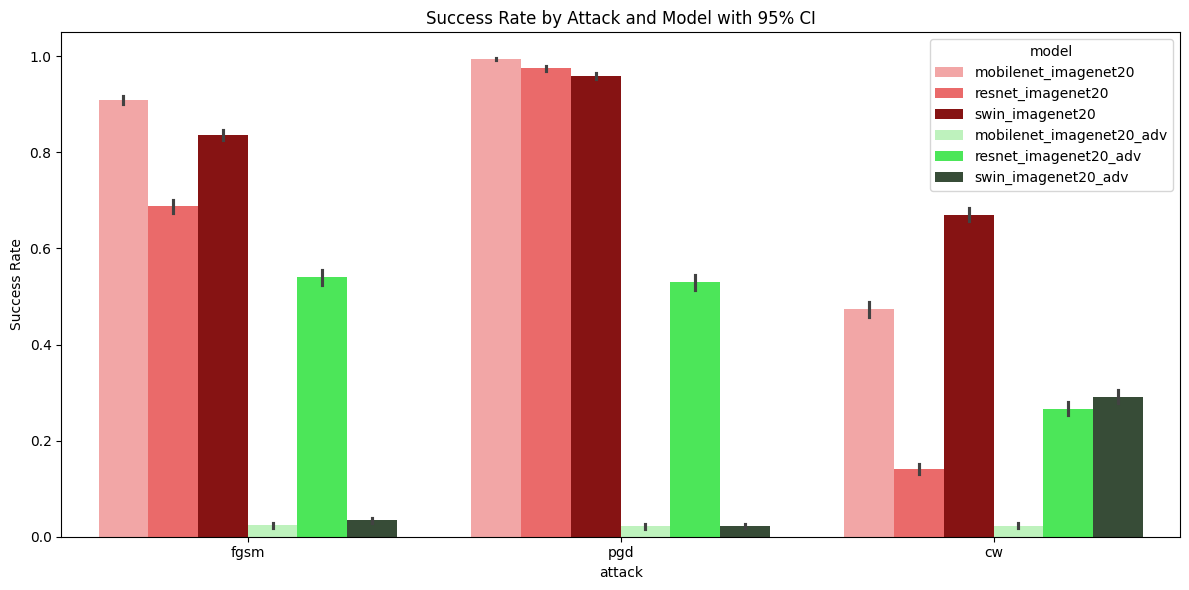

In [ ]:
model_order = [
    "mobilenet_imagenet20",
    "resnet_imagenet20",
    "swin_imagenet20",
    "mobilenet_imagenet20_adv",
    "resnet_imagenet20_adv",
    "swin_imagenet20_adv"
]

custom_palette = {
    "mobilenet_imagenet20": "#FF9999",         
    "resnet_imagenet20": "#FF5555",           
    "swin_imagenet20": "#990000",              
    "mobilenet_imagenet20_adv": "#B6FBB4",   
    "resnet_imagenet20_adv": "#33FF44",     
    "swin_imagenet20_adv": "#344F34",     
}

# Order for the x-axis
attack_order = ["fgsm", "pgd", "cw"]

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_total, 
    x="attack",
    y="attack_successful",
    hue="model",
    errorbar=('ci', 95),
    estimator=lambda x: x.mean(),
    palette=custom_palette,
    hue_order=model_order,
    order=attack_order  
)

plt.title("Success Rate by Attack and Model with 95% CI")
plt.ylabel("Success Rate")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()




# Statistical tests

In [ ]:
psnr_adv = df_models.groupby('attack')['psnr_score'].mean()
print(psnr_adv)

attack
cw      73.448618
fgsm    84.937477
pgd     86.961739
Name: psnr_score, dtype: float64


In [79]:
psnr_base = df_base.groupby('attack')['psnr_score'].mean()
print(psnr_base)

attack
cw      75.263213
fgsm    85.846883
pgd     91.256196
Name: psnr_score, dtype: float64


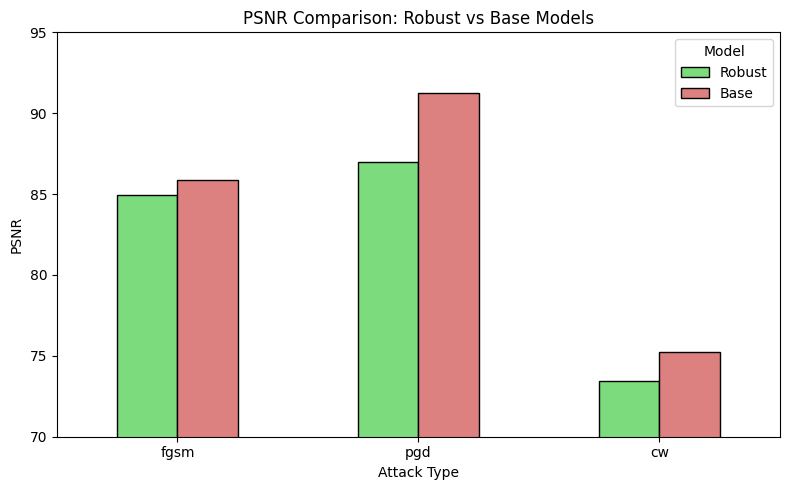

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


psnr_adv = pd.Series({
    'cw': 73.448618,
    'fgsm': 84.937477,
    'pgd': 86.961739
}, name="Adversarial")

psnr_success = pd.Series({
    'cw': 75.263213,
    'fgsm': 85.846883,
    'pgd': 91.256196
}, name="Base")

# Combine and reorder
df = pd.concat([psnr_adv, psnr_success], axis=1)
df.columns = ["Robust", "Base"]

attack_order = ["fgsm", "pgd", "cw"]
df = df.loc[attack_order]

# Plotting
ax = df.plot(
    kind="bar", 
    figsize=(8, 5), 
    color=["#7CDB7C", "#DD8080"],  # Light green and light red
    edgecolor="black"
)

# Formatting
plt.title("PSNR Comparison: Robust vs Base Models")
plt.ylabel("PSNR")
plt.xlabel("Attack Type")
plt.xticks(rotation=0)
plt.ylim(70, 95)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


In [ ]:
model = smf.mixedlm(
    "psnr_score ~ model * attack",     
    df_total,
    groups="dataset_index"                 
)
result = model.fit()

# Print the summary
print(result.summary())


                            Mixed Linear Model Regression Results
Model:                         MixedLM            Dependent Variable:            psnr_score  
No. Observations:              70848              Method:                        REML        
No. Groups:                    3936               Scale:                         1.5086      
Min. group size:               18                 Log-Likelihood:                -117621.7451
Max. group size:               18                 Converged:                     Yes         
Mean group size:               18.0                                                          
---------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.    z     P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                                        75.583    0.021 3615.036 0.000 75.542 7

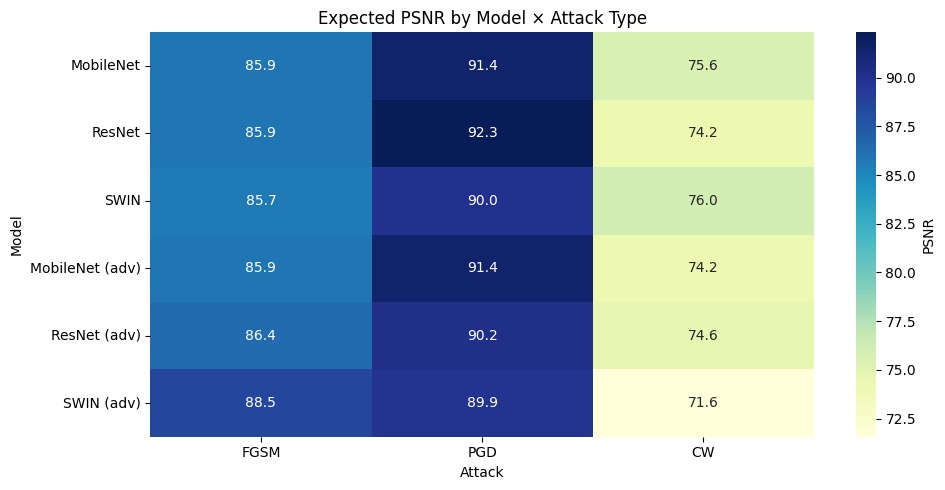

In [ ]:
data = {
    "MobileNet":         [75.583, 85.875, 91.445],
    "ResNet":            [74.227, 85.928, 92.326],
    "SWIN":              [75.981, 85.740, 89.999],
    "MobileNet (adv)":   [74.206, 85.875, 91.445],
    "ResNet (adv)":      [74.573, 86.446, 90.209],
    "SWIN (adv)":        [71.568, 88.541, 89.871],
}
attacks = ['CW', 'FGSM', 'PGD']

# Create DataFrame and transpose
df = pd.DataFrame(data, index=attacks)

desired_order = ['FGSM', 'PGD', 'CW']
df = df.loc[desired_order]

# Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.T, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'PSNR'})
plt.title('Expected PSNR by Model × Attack Type')
plt.ylabel('Model')
plt.xlabel('Attack')
plt.tight_layout()
plt.show()


# KL divergence

In [105]:
df_total["original_probs"] = df_total["original_probs"].apply(ast.literal_eval)
df_total["adversarial_probs"] = df_total["adversarial_probs"].apply(ast.literal_eval)

In [106]:
def kl_divergence(p, q):
    # Convert to tensors
    p = torch.tensor(p, dtype=torch.float32)
    q = torch.tensor(q, dtype=torch.float32)

    # Add small epsilon to avoid log(0)
    epsilon = 1e-8
    p = p + epsilon
    q = q + epsilon

    return F.kl_div(q.log(), p, reduction="sum").item()  

In [107]:
df_total["kl_divergence"] = df_total.apply(lambda row: kl_divergence(row["original_probs"], row["adversarial_probs"]), axis=1)


In [109]:
print(df_total.groupby("attack")["kl_divergence"].mean())

attack
cw      1.393169
fgsm    2.028393
pgd     3.922134
Name: kl_divergence, dtype: float64


In [110]:
model = smf.mixedlm("kl_divergence ~ model * attack", data=df_total, groups=df_total["dataset_index"])
result = model.fit()

print(result.summary())

C:\Users\celin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\celin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                            Mixed Linear Model Regression Results
Model:                        MixedLM            Dependent Variable:            kl_divergence
No. Observations:             70848              Method:                        REML         
No. Groups:                   3936               Scale:                         5.5241       
Min. group size:              18                 Log-Likelihood:                -163409.6945 
Max. group size:              18                 Converged:                     Yes          
Mean group size:              18.0                                                           
---------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.    z     P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                                         2.101    0.040   52.919 0.000  2.024  

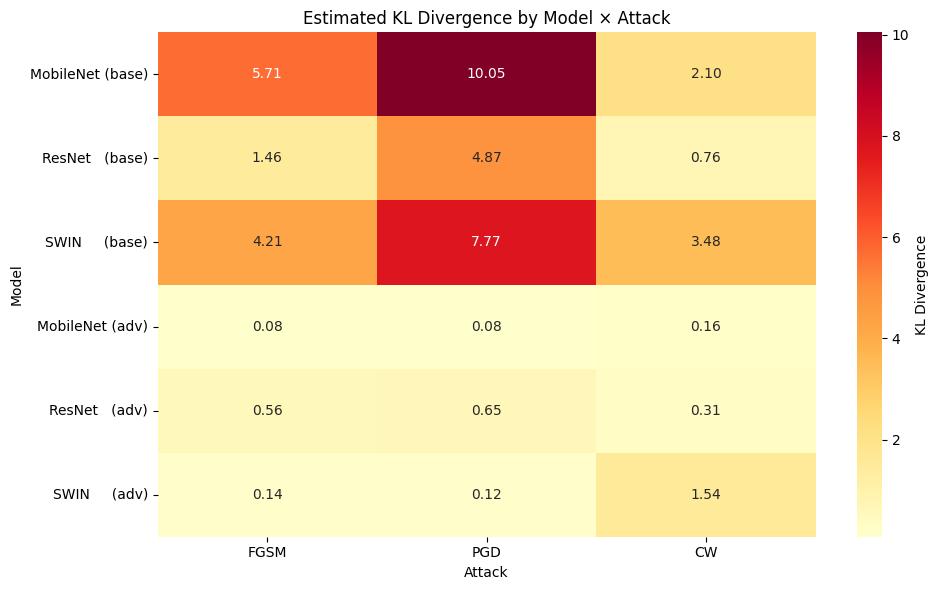

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reconstructed KL divergence
data = [
    [ 5.708, 10.048, 2.101],  # MobileNet (base)
    [ 1.462,  4.865, 0.760],  # ResNet   (base)
    [ 4.213,  7.768, 3.484],  # SWIN     (base)
    [ 0.080,  0.079, 0.162],  # MobileNet (adv)
    [ 0.565,  0.646, 0.311],  # ResNet   (adv)
    [ 0.139,  0.124, 1.538],  # SWIN     (adv)
]

models = [
    "MobileNet (base)",
    "ResNet   (base)",
    "SWIN     (base)",
    "MobileNet (adv)",
    "ResNet   (adv)",
    "SWIN     (adv)",
]

# Column order: FGSM, PGD, CW
attacks = ["FGSM", "PGD", "CW"]

# Create DataFrame
df = pd.DataFrame(data, index=models, columns=attacks)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={"label": "KL Divergence"},
)
plt.title("Estimated KL Divergence by Model × Attack")
plt.ylabel("Model")
plt.xlabel("Attack")
plt.tight_layout()
plt.show()
